# Gripper Width Debug

This notebook compares three current artifacts for the first 10 converted demos:

- HDF5 `/obs/gripper_qpos[:, 0]`, still normalized in `[0, 1]`.
- Zarr `/data/robot0_gripper_width[:, 0]`, in meters.
- Offline inference `pred_action[..., -1]` and `gt_action[..., -1]`, in meters.

Important: the current converter resolves parent-folder HDF5 paths with plain `sorted(...)`, so these plots use lexicographic file order to match the zarr episode order.

In [10]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "alternative_data_workspace").exists() and (path / "custom_data_pipeline").exists():
            return path
    raise RuntimeError("Could not find repo root from current working directory")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs

register_codecs()

HDF5_DIR = ROOT / "alternative_data_workspace"
ZARR_PATH = ROOT / "custom_data_pipeline/complete_training_dataset.zarr.zip"
NPZ_PATH = ROOT / "custom_data_pipeline/gripper_width_debug/offline_predictions.npz"
NUM_DEMOS = 10
NUM_ACTION_CHUNKS_TO_PLOT = 25
UMI_GRIPPER_SCALE_MM = 90.0

print("ROOT:", ROOT)
print("HDF5_DIR:", HDF5_DIR)
print("ZARR_PATH:", ZARR_PATH)
print("NPZ_PATH:", NPZ_PATH)

numcodec 'imagecodecs_aec' already registered
numcodec 'imagecodecs_apng' already registered
numcodec 'imagecodecs_avif' already registered
numcodec 'imagecodecs_bitorder' already registered
numcodec 'imagecodecs_bitshuffle' already registered
numcodec 'imagecodecs_blosc' already registered
numcodec 'imagecodecs_blosc2' already registered
numcodec 'imagecodecs_brotli' already registered
numcodec 'imagecodecs_byteshuffle' already registered
numcodec 'imagecodecs_bz2' already registered
numcodec 'imagecodecs_cms' already registered
numcodec 'imagecodecs_deflate' already registered
numcodec 'imagecodecs_delta' already registered
numcodec 'imagecodecs_float24' already registered
numcodec 'imagecodecs_floatpred' already registered
numcodec 'imagecodecs_gif' already registered
numcodec 'imagecodecs_heif' already registered
numcodec 'imagecodecs_jetraw' already registered
numcodec 'imagecodecs_jpeg' already registered
numcodec 'imagecodecs_jpeg2k' already registered
numcodec 'imagecodecs_jpeg

ROOT: /home/yifan/RoboTouch Lab/universal_manipulation_interface
HDF5_DIR: /home/yifan/RoboTouch Lab/universal_manipulation_interface/alternative_data_workspace
ZARR_PATH: /home/yifan/RoboTouch Lab/universal_manipulation_interface/custom_data_pipeline/complete_training_dataset.zarr.zip
NPZ_PATH: /home/yifan/RoboTouch Lab/universal_manipulation_interface/custom_data_pipeline/gripper_width_debug/offline_predictions.npz


In [11]:
# Load HDF5 normalized gripper values in the same order used by the conversion script.
hdf5_paths = (sorted(HDF5_DIR.glob("*.hdf5")) + sorted(HDF5_DIR.glob("*.h5")))[:NUM_DEMOS]
hdf5_qpos = []

for path in hdf5_paths:
    with h5py.File(path, "r") as f:
        hdf5_qpos.append(f["obs/gripper_qpos"][:, 0].astype(np.float32))

# Load zarr gripper widths.
with zarr.ZipStore(str(ZARR_PATH), mode="r") as store:
    root = zarr.group(store=store)
    zarr_gripper_m = root["data/robot0_gripper_width"][:, 0]
    episode_ends = root["meta/episode_ends"][:]

episode_starts = np.r_[0, episode_ends[:-1]]
zarr_episodes_m = [
    zarr_gripper_m[episode_starts[i]:episode_ends[i]]
    for i in range(NUM_DEMOS)
]

# Load offline predictions.
pred_data = np.load(NPZ_PATH)
pred_action = pred_data["pred_action"]
gt_action = pred_data["gt_action"]
pred_episode_id = pred_data["episode_id"]
pred_episode_timestep = pred_data["episode_timestep"]

print("HDF5 files:", [p.name for p in hdf5_paths])
print("zarr total episodes:", len(episode_ends))
print("prediction shapes:", pred_action.shape, gt_action.shape)

HDF5 files: ['episode_0.hdf5', 'episode_1.hdf5', 'episode_10.hdf5', 'episode_11.hdf5', 'episode_12.hdf5', 'episode_13.hdf5', 'episode_14.hdf5', 'episode_15.hdf5', 'episode_16.hdf5', 'episode_17.hdf5']
zarr total episodes: 50
prediction shapes: (23844, 16, 10) (23844, 16, 10)


In [12]:
rows = []
pred_by_episode = {}

for demo_idx in range(NUM_DEMOS):
    mask = pred_episode_id == demo_idx
    order = np.argsort(pred_episode_timestep[mask])
    sample_t = pred_episode_timestep[mask][order]
    pred_chunk_m = pred_action[mask, :, -1][order]
    gt_chunk_m = gt_action[mask, :, -1][order]
    pred_h0_m = pred_chunk_m[:, 0]
    gt_h0_m = gt_chunk_m[:, 0]
    pred_by_episode[demo_idx] = {
        "t": sample_t,
        "pred_chunk_m": pred_chunk_m,
        "gt_chunk_m": gt_chunk_m,
        "pred_h0_m": pred_h0_m,
        "gt_h0_m": gt_h0_m,
    }

    qpos = hdf5_qpos[demo_idx]
    z_ep = zarr_episodes_m[demo_idx]
    rows.append({
        "demo_idx": demo_idx,
        "hdf5_file": hdf5_paths[demo_idx].name,
        "hdf5_len": len(qpos),
        "zarr_len": len(z_ep),
        "npz_samples": len(sample_t),
        "hdf5_start_qpos": float(qpos[0]),
        "hdf5_start_as_90mm": float(qpos[0] * UMI_GRIPPER_SCALE_MM),
        "zarr_start_mm": float(z_ep[0] * 1000.0),
        "pred_h0_start_mm": float(pred_h0_m[0] * 1000.0) if len(pred_h0_m) else np.nan,
        "gt_h0_start_mm": float(gt_h0_m[0] * 1000.0) if len(gt_h0_m) else np.nan,
        "pred_gt_h0_mae_mm": float(np.mean(np.abs(pred_h0_m - gt_h0_m)) * 1000.0) if len(pred_h0_m) else np.nan,
    })

summary = pd.DataFrame(rows)
summary

,demo_idx,hdf5_file,hdf5_len,zarr_len,npz_samples,hdf5_start_qpos,hdf5_start_as_90mm,zarr_start_mm,pred_h0_start_mm,gt_h0_start_mm,pred_gt_h0_mae_mm
0,0,episode_0.hdf5,609,609,564,0.955084,85.957525,85.957527,85.815147,85.957527,0.096438
1,1,episode_1.hdf5,649,649,604,0.954018,85.861657,85.861661,85.888296,85.861661,0.094741
2,2,episode_10.hdf5,610,610,565,0.954044,85.863937,85.863940,85.910015,85.863940,0.079606
3,3,episode_11.hdf5,661,661,616,0.954495,85.904567,85.904568,85.874684,85.904568,0.104270
4,4,episode_12.hdf5,534,534,489,0.954034,85.863025,85.863031,85.905045,85.863031,0.111532
5,5,episode_13.hdf5,586,586,541,0.954450,85.900458,85.900463,85.960254,85.900463,0.104202
6,6,episode_14.hdf5,688,688,643,0.954024,85.862119,85.862122,85.829914,85.862122,0.071629
7,7,episode_15.hdf5,672,672,627,0.954546,85.909132,85.909136,85.882239,85.909136,0.065023
8,8,episode_16.hdf5,556,556,511,0.954054,85.864844,85.864849,85.899666,85.864849,0.081957
9,9,episode_17.hdf5,590,590,545,0.954018,85.861657,85.861661,85.821748,85.861661,0.100126


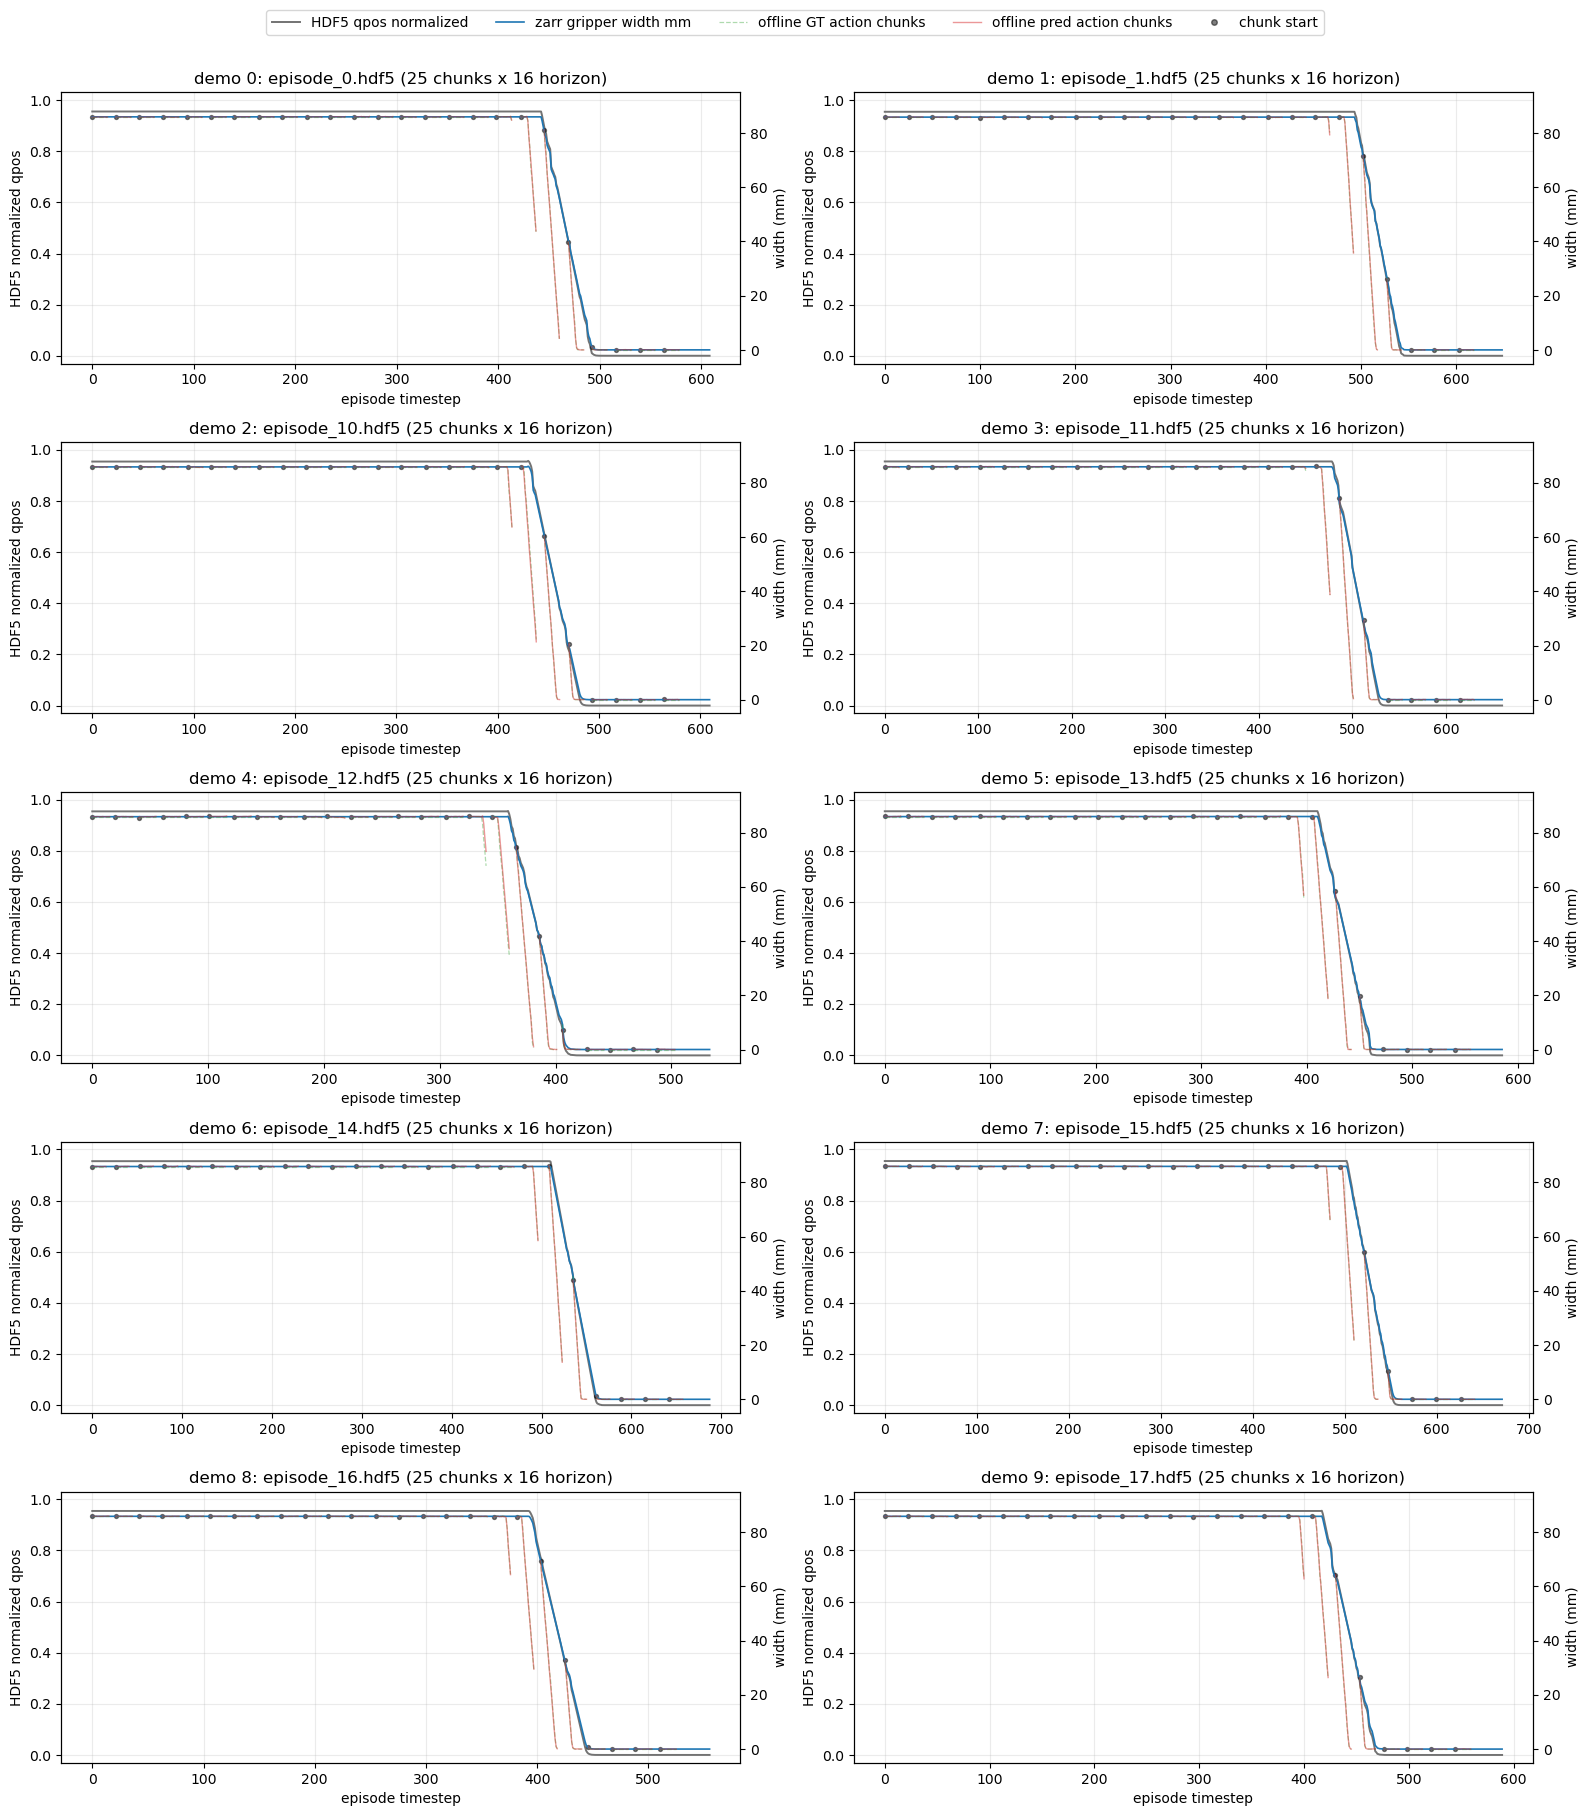

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=False)
axes = axes.ravel()
horizon = pred_action.shape[1]

for demo_idx, ax in enumerate(axes[:NUM_DEMOS]):
    qpos = hdf5_qpos[demo_idx]
    z_ep_mm = zarr_episodes_m[demo_idx] * 1000.0
    pred_ep = pred_by_episode[demo_idx]

    ax2 = ax.twinx()
    ax.plot(np.arange(len(qpos)), qpos, color="0.45", linewidth=1.4)
    ax2.plot(np.arange(len(z_ep_mm)), z_ep_mm, color="tab:blue", linewidth=1.2)

    sample_t = pred_ep["t"]
    n_chunks = min(NUM_ACTION_CHUNKS_TO_PLOT, len(sample_t))
    if n_chunks > 0:
        chunk_indices = np.unique(np.linspace(0, len(sample_t) - 1, n_chunks, dtype=int))
        for chunk_idx in chunk_indices:
            t0 = sample_t[chunk_idx]
            x = t0 + np.arange(horizon)
            ax2.plot(
                x,
                pred_ep["gt_chunk_m"][chunk_idx] * 1000.0,
                color="tab:green",
                linestyle="--",
                linewidth=0.9,
                alpha=0.38,
            )
            ax2.plot(
                x,
                pred_ep["pred_chunk_m"][chunk_idx] * 1000.0,
                color="tab:red",
                linewidth=1.0,
                alpha=0.48,
            )
            ax2.scatter([t0], [pred_ep["pred_chunk_m"][chunk_idx, 0] * 1000.0], color="black", s=8, alpha=0.5)

    ax.set_title(f"demo {demo_idx}: {hdf5_paths[demo_idx].name} ({n_chunks} chunks x {horizon} horizon)")
    ax.set_xlabel("episode timestep")
    ax.set_ylabel("HDF5 normalized qpos")
    ax2.set_ylabel("width (mm)")
    ax.set_ylim(-0.03, 1.03)
    ax2.set_ylim(-5, 95)
    ax.grid(True, alpha=0.25)

# Rebuild legend handles explicitly because each subplot has a twin y-axis.
legend_handles = [
    plt.Line2D([], [], color="0.45", linewidth=1.4, label="HDF5 qpos normalized"),
    plt.Line2D([], [], color="tab:blue", linewidth=1.2, label="zarr gripper width mm"),
    plt.Line2D([], [], color="tab:green", linestyle="--", linewidth=0.9, alpha=0.38, label="offline GT action chunks"),
    plt.Line2D([], [], color="tab:red", linewidth=1.0, alpha=0.48, label="offline pred action chunks"),
    plt.Line2D([], [], color="black", marker="o", linestyle="", markersize=4, alpha=0.5, label="chunk start"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.01))
fig.tight_layout(rect=(0, 0, 1, 0.98))

In [14]:
print("Mean abs pred-vs-GT h0 gripper error over first 10 demos:")
print(summary[["demo_idx", "hdf5_file", "pred_gt_h0_mae_mm"]].to_string(index=False))
print("\nOverall first-10 demo MAE:", summary["pred_gt_h0_mae_mm"].mean(), "mm")

print("\nScale check:")
print("Mean HDF5 start qpos * 90 mm:", summary["hdf5_start_as_90mm"].mean())
print("Mean zarr start mm:", summary["zarr_start_mm"].mean())
print("Mean offline GT h0 start mm:", summary["gt_h0_start_mm"].mean())
print("Mean offline pred h0 start mm:", summary["pred_h0_start_mm"].mean())

Mean abs pred-vs-GT h0 gripper error over first 10 demos:
 demo_idx       hdf5_file  pred_gt_h0_mae_mm
        0  episode_0.hdf5           0.096438
        1  episode_1.hdf5           0.094741
        2 episode_10.hdf5           0.079606
        3 episode_11.hdf5           0.104270
        4 episode_12.hdf5           0.111532
        5 episode_13.hdf5           0.104202
        6 episode_14.hdf5           0.071629
        7 episode_15.hdf5           0.065023
        8 episode_16.hdf5           0.081957
        9 episode_17.hdf5           0.100126

Overall first-10 demo MAE: 0.09095254208659753 mm

Scale check:
Mean HDF5 start qpos * 90 mm: 85.88489216566086
Mean zarr start mm: 85.88489592075348
Mean offline GT h0 start mm: 85.88489592075348
Mean offline pred h0 start mm: 85.87870076298714


## Reading the plot

For a correctly matched pipeline, the blue zarr curve should align with the green offline GT action chunks, because the offline GT action is sampled from the zarr. Each green/red branch starts at one selected sample timestep and runs across the full prediction horizon. The red prediction chunks should be close to green if the model learned the gripper trajectory. The gray HDF5 curve is normalized, but under the current UMI convention `qpos * 90 mm` should match the blue zarr curve.